# News Credibility Classification

## Kaggle Fake and Real News Dataset

This notebook implements a **machine learning pipeline** that classifies news articles as **Fake (0)** or **Real (1)** using the [Kaggle Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset).

---

## Document Structure

| Section | Description |
|--------|-------------|
| **Data Loading** | Load Fake.csv & True.csv, merge, label, shuffle |
| **EDA** | Class distribution, word count, title length |
| **Preprocessing** | Lowercase, punctuation, stopwords, lemmatization |
| **Feature Engineering** | TF-IDF, vocabulary size |
| **Train/Test Split** | Stratified split |
| **Model Training** | LR, Naive Bayes, Random Forest, SVM |
| **Evaluation** | Accuracy, Precision, Recall, F1, Confusion Matrix |
| **Model Comparison** | Bar chart, table, best model |
| **Final Model** | Save best model for Streamlit |


---
## Step 1: Install & Import Libraries


In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn nltk joblib -q


In [2]:
import sys
from pathlib import Path
# Repo root: cwd if dataset/ here, else parent (e.g. when run from notebook/)
repo_root = Path.cwd() if (Path.cwd() / 'dataset').exists() else Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve
)
import joblib

from src.data.loader import load_dataset
from src.features.preprocessing import clean_text, prepare_text_column
from src.models.pipelines import build_lr_pipeline, build_nb_pipeline, build_rf_pipeline, build_svm_pipeline

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


---
## Step 2: Data Loading

Load **Fake.csv** and **True.csv**, add label (Fake=0, Real=1), merge, shuffle, and display shape and sample.


In [3]:
dataset_dir = repo_root / 'dataset'
df = load_dataset(str(dataset_dir))
print('Dataset Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nLabel distribution:');
print(df['label'].value_counts())
df.head(10)


Dataset Shape: (39105, 6)

Columns: ['title', 'text', 'subject', 'date', 'label', 'combined_text']

Label distribution:
label
1    21197
0    17908
Name: count, dtype: int64


,title,text,subject,date,label,combined_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Lea...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,"On Wednesday, Democrats took a powerful stance...",News,"June 22, 2016",0,Paul Ryan Responds To Dem’s Sit-In On Gun Cont...
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,President Trump s rally in FL on Saturday was ...,Government News,"Feb 19, 2017",0,AWESOME! DIAMOND AND SILK Rip Into The Press: ...
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",0,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...
8,North Korea shows no sign it is serious about ...,WASHINGTON (Reuters) - The State Department sa...,worldnews,"December 13, 2017",1,North Korea shows no sign it is serious about ...
9,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,politicsNews,"May 4, 2016",1,Trump signals willingness to raise U.S. minimu...


---
## Step 3: Exploratory Data Analysis (EDA)

- Class distribution
- Word count distribution
- Title length analysis
- Text statistics


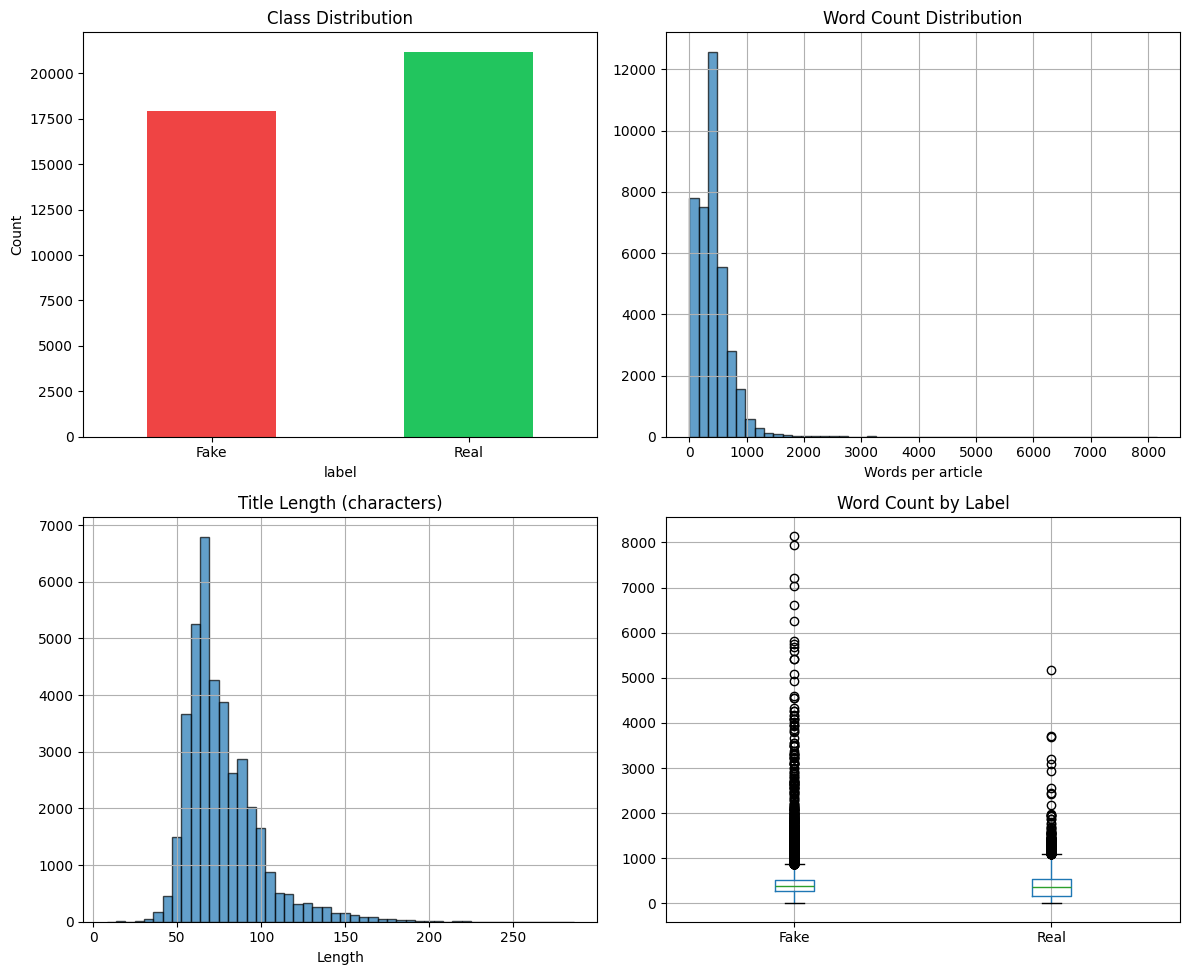

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Class distribution
ax0 = axes[0, 0]
df['label'].value_counts().sort_index().plot(kind='bar', ax=ax0, color=['#ef4444', '#22c55e'])
ax0.set_xticklabels(['Fake', 'Real'], rotation=0)
ax0.set_title('Class Distribution')
ax0.set_ylabel('Count')

# Word count (combined_text)
df['word_count'] = df['combined_text'].str.split().str.len()
ax1 = axes[0, 1]
df['word_count'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.set_title('Word Count Distribution')
ax1.set_xlabel('Words per article')

# Title length
df['title_len'] = df['title'].str.len()
ax2 = axes[1, 0]
df['title_len'].hist(bins=50, ax=ax2, edgecolor='black', alpha=0.7)
ax2.set_title('Title Length (characters)')
ax2.set_xlabel('Length')

# Word count by label
ax3 = axes[1, 1]
df.boxplot(column='word_count', by='label', ax=ax3)
ax3.set_xticklabels(['Fake', 'Real'])
ax3.set_title('Word Count by Label')
ax3.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.savefig(repo_root / 'plots' / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
print('Text statistics:')
print(df['word_count'].describe())


Text statistics:
count    39105.000000
mean       410.476614
std        315.167468
min          2.000000
25%        220.000000
50%        378.000000
75%        521.000000
max       8148.000000
Name: word_count, dtype: float64


---
## Step 4: Data Preprocessing

- Lowercasing
- Remove punctuation
- Remove stopwords
- Lemmatization


In [6]:
df = prepare_text_column(df, text_column='combined_text', label_column='label', cleaned_col='cleaned_text', drop_empty=True)
print('After cleaning, shape:', df.shape)
print('\nSample cleaned text:');
print(df['cleaned_text'].iloc[0][:400])


After cleaning, shape: (39100, 9)

Sample cleaned text:
ben stein call circuit court committed coup tat constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washington state coup tat executive branch const


---
## Step 5: Feature Engineering — TF-IDF

TF-IDF vectorization (unigrams + bigrams). Vocabulary size reported after fitting.


In [7]:
X = df['cleaned_text']
y = df['label']

# Vocabulary size will be shown after we fit a pipeline (Step 7)
print('Features (X) and labels (y) extracted. TF-IDF applied inside each model pipeline.')


Features (X) and labels (y) extracted. TF-IDF applied inside each model pipeline.


---
## Step 6: Train/Test Split

Stratified split (80/20). Data was already shuffled in load_dataset.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set: {len(X_train)}')
print(f'Test set:     {len(X_test)}')
print('\nTrain label distribution:');
print(y_train.value_counts())


Training set: 31280
Test set:     7820

Train label distribution:
label
1    16958
0    14322
Name: count, dtype: int64


---
## Step 7: Model Training

Train: **Logistic Regression**, **Naive Bayes**, **Random Forest**, **SVM**.


In [9]:
pipelines = {
    'Logistic Regression': build_lr_pipeline(random_state=42),
    'Naive Bayes': build_nb_pipeline(),
    'Random Forest': build_rf_pipeline(random_state=42),
    'SVM': build_svm_pipeline(random_state=42),
}
predictions = {}
probabilities = {}

for name, pipe in pipelines.items():
    print(f'Training {name}...')
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)
    if hasattr(pipe, 'predict_proba'):
        probabilities[name] = pipe.predict_proba(X_test)[:, 1]
    else:
        probabilities[name] = pipe.decision_function(X_test)  # SVM
print('✅ All models trained!')


Training Logistic Regression...
Training Naive Bayes...
Training Random Forest...
Training SVM...
✅ All models trained!


---
## Step 8: Model Evaluation

For each model: Accuracy, Precision, Recall, F1, Confusion Matrix, Classification Report.


In [10]:
results = {}
for name in pipelines:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    if y_proba.max() > 1 or y_proba.min() < 0:
        y_proba_norm = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-8)
        auc = roc_auc_score(y_test, y_proba_norm)
    else:
        auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': auc,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }


In [11]:
# Add 5-fold cross-validation F1 to results (for dashboard CV F1 metric and model comparison chart)
for name in pipelines:
    cv_scores = cross_val_score(pipelines[name], X, y, cv=5, scoring='f1', n_jobs=-1)
    results[name]['CV F1'] = [float(cv_scores.mean()), float(cv_scores.std())]
print('✅ CV F1 computed for all models')

✅ CV F1 computed for all models


In [12]:
for name in results:
    print('='*60)
    print(name)
    print('='*60)
    r = results[name]
    print(f"Accuracy:  {r['Accuracy']:.4f}")
    print(f"Precision: {r['Precision']:.4f}")
    print(f"Recall:    {r['Recall']:.4f}")
    print(f"F1 Score:  {r['F1 Score']:.4f}")
    print(f"ROC-AUC:  {r['ROC-AUC']:.4f}")
    print('\nClassification Report:')
    print(classification_report(y_test, predictions[name], target_names=['Fake', 'Real']))


Logistic Regression
Accuracy:  0.9921
Precision: 0.9897
Recall:    0.9958
F1 Score:  0.9927
ROC-AUC:  0.9994

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3581
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820

Naive Bayes
Accuracy:  0.9596
Precision: 0.9651
Recall:    0.9601
F1 Score:  0.9626
ROC-AUC:  0.9922

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.96      0.96      3581
        Real       0.97      0.96      0.96      4239

    accuracy                           0.96      7820
   macro avg       0.96      0.96      0.96      7820
weighted avg       0.96      0.96      0.96      7820

Random Forest
Accuracy:  0.9919
Precision: 0.9890
Recall:    0.9962
F1 Score:  0.9926
RO

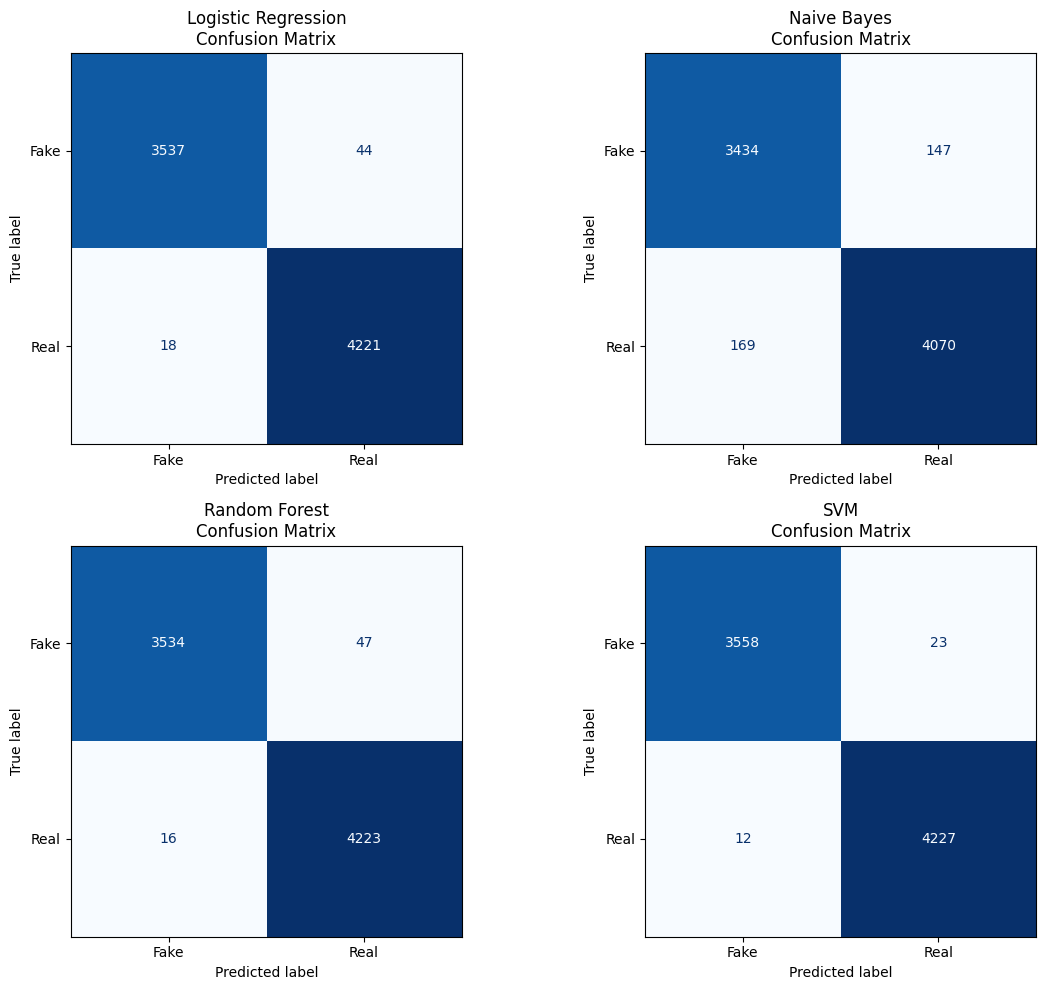

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for idx, name in enumerate(pipelines):
    cm = results[name]['confusion_matrix']
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}\nConfusion Matrix')
plt.tight_layout()
plt.savefig(repo_root / 'plots' / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


#### ROC Curves

Plot ROC curve for each model using test set predictions and probabilities. AUC summarizes discriminative ability.

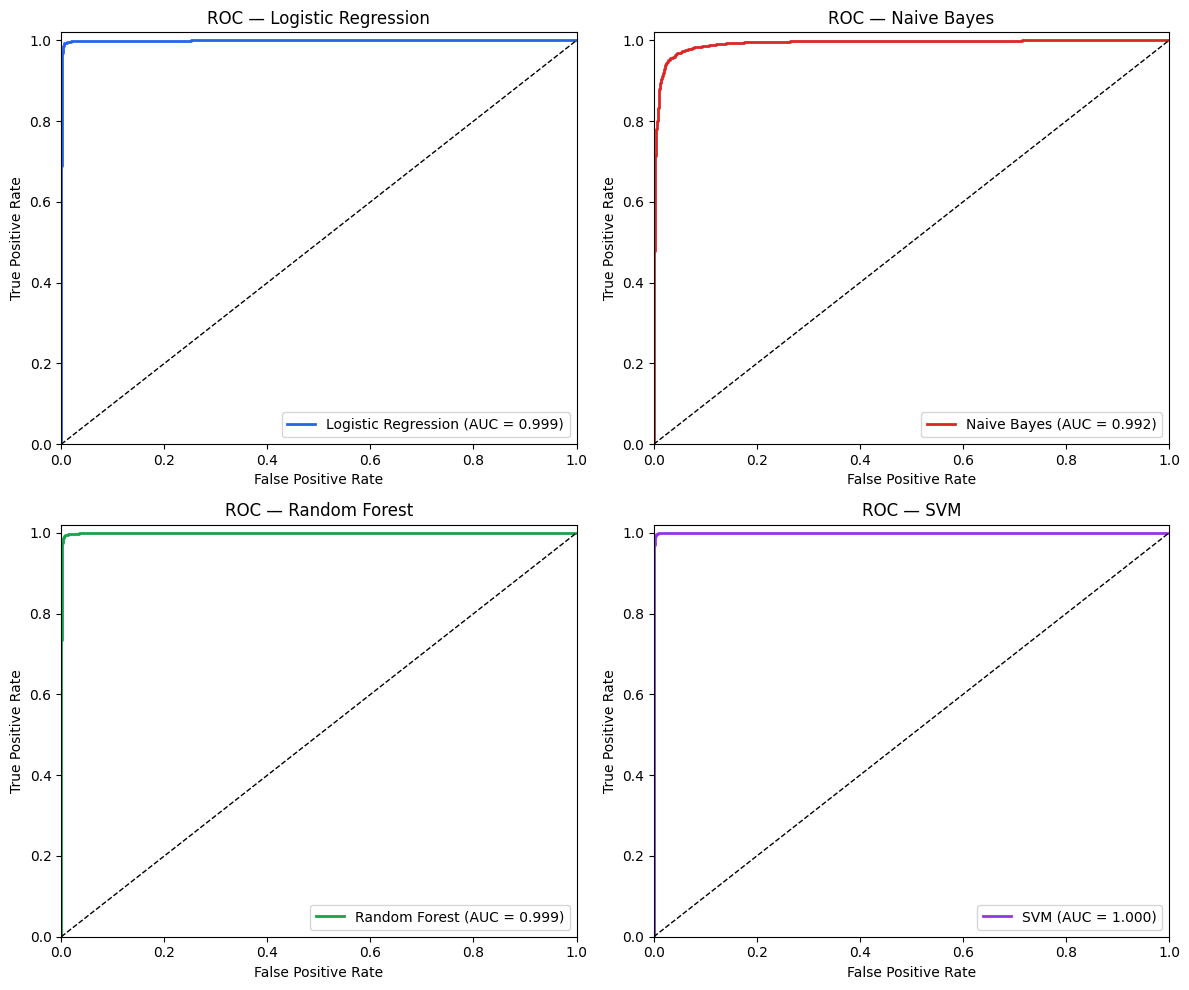

In [14]:
# ROC curves: one subplot per model (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
colors = ['#2563eb', '#dc2626', '#16a34a', '#9333ea']
for idx, name in enumerate(pipelines):
    y_proba = probabilities[name]
    # SVM decision_function can be unbounded; normalize to [0,1] for ROC
    if y_proba.max() > 1 or y_proba.min() < 0:
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-8)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    axes[idx].plot(fpr, tpr, color=colors[idx], lw=2, label=f'{name} (AUC = {auc_val:.3f})')
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'ROC — {name}')
    axes[idx].legend(loc='lower right')
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(repo_root / 'plots' / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Precision-Recall Curves

Precision-Recall curves are useful for imbalanced data. Higher area under the curve indicates better precision/recall trade-off.

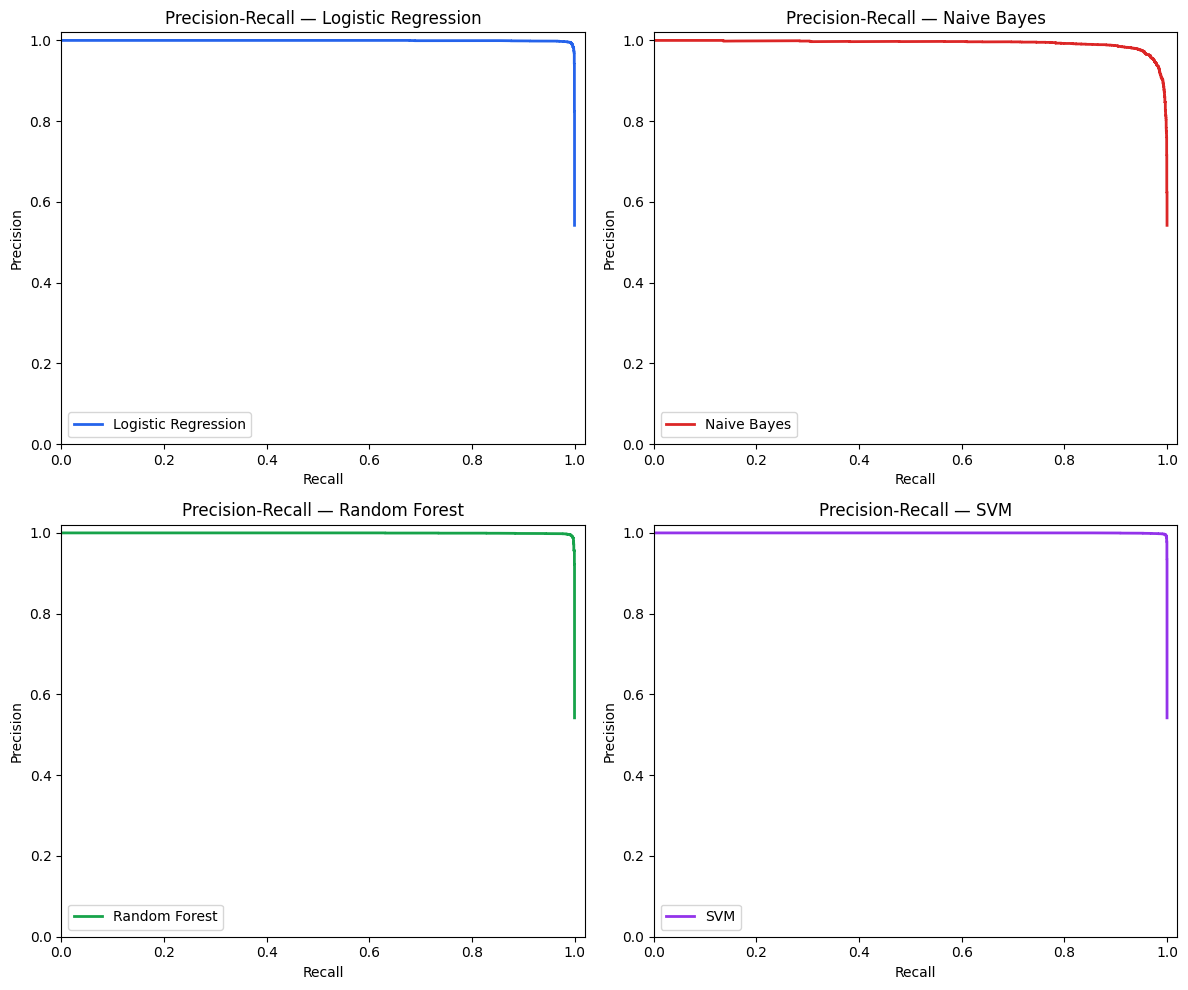

In [15]:
# Precision-Recall curves: one subplot per model (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for idx, name in enumerate(pipelines):
    y_proba = probabilities[name]
    if y_proba.max() > 1 or y_proba.min() < 0:
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-8)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[idx].plot(rec, prec, color=colors[idx], lw=2, label=name)
    axes[idx].set_xlabel('Recall')
    axes[idx].set_ylabel('Precision')
    axes[idx].set_title(f'Precision-Recall — {name}')
    axes[idx].legend(loc='lower left')
    axes[idx].set_xlim([0, 1.02])
    axes[idx].set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(repo_root / 'plots' / 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Model Comparison

Accuracy comparison bar chart, performance table, best model selection.


In [16]:
comparison_df = pd.DataFrame({
    name: [r['Accuracy'], r['Precision'], r['Recall'], r['F1 Score'], r['ROC-AUC']]
    for name, r in results.items()
}).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
comparison_df = comparison_df.round(4)
comparison_df


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.9921,0.9897,0.9958,0.9927,0.9994
Naive Bayes,0.9596,0.9651,0.9601,0.9626,0.9922
Random Forest,0.9919,0.9890,0.9962,0.9926,0.9995
SVM,0.9955,0.9946,0.9972,0.9959,0.9998


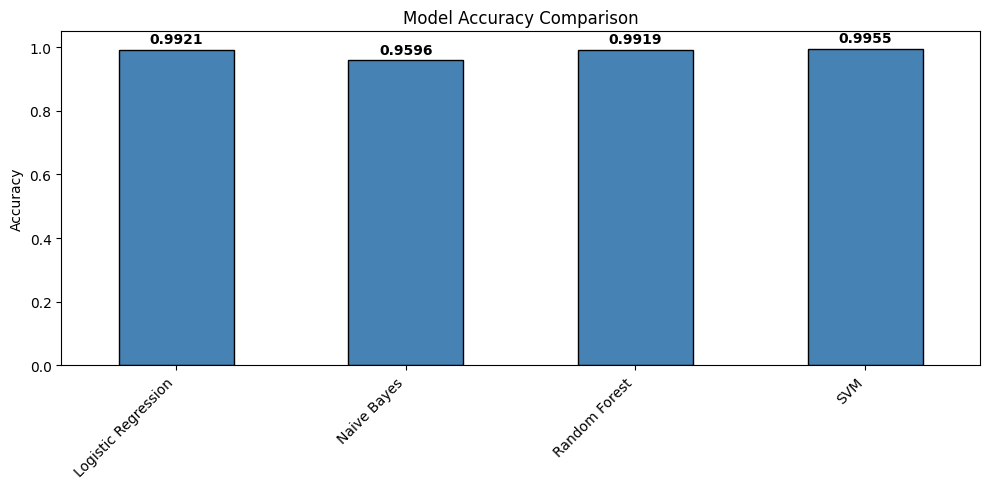

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = comparison_df['Accuracy'].plot(
    kind='bar',
    ax=ax,
    color='steelblue',
    edgecolor='black'
)

ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0, 1.05)

# Show values on top of bars
for i, v in enumerate(comparison_df['Accuracy']):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(repo_root / 'plots' / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
best_model_name = comparison_df['F1 Score'].idxmax()
print(f'Best model (by F1 Score): {best_model_name}')


Best model (by F1 Score): SVM


---
## Step 10: Vocabulary Size & Feature Importance (Logistic Regression)


In [19]:
lr_pipe = pipelines['Logistic Regression']
vocab_size = len(lr_pipe.named_steps['tfidf'].get_feature_names_out())
print(f'Vocabulary size (TF-IDF): {vocab_size}')


Vocabulary size (TF-IDF): 25000


In [20]:
if best_model_name == 'Logistic Regression':
    coef = lr_pipe.named_steps['clf'].coef_[0]
    feat_names = lr_pipe.named_steps['tfidf'].get_feature_names_out()
    top_idx = np.argsort(np.abs(coef))[-20:]
    top_df = pd.DataFrame({'feature': feat_names[top_idx], 'coef': coef[top_idx]})
    top_df = top_df.sort_values('coef')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_df['feature'], top_df['coef'], color=['#ef4444' if c < 0 else '#22c55e' for c in top_df['coef']])
    ax.set_title('Top 20 Features (LR coefficients)\nRed=Fake, Green=Real')
    plt.tight_layout()
    plt.savefig(repo_root / 'plots' / 'top_features.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Step 11: Save Best Model for Streamlit


In [21]:
best_pipeline = pipelines[best_model_name]
model_dir = repo_root / 'model'
model_dir.mkdir(exist_ok=True)
model_path = model_dir / 'pipeline.pkl'
joblib.dump(best_pipeline, model_path)
print(f'✅ Best model ({best_model_name}) saved to {model_path}')


✅ Best model (SVM) saved to /Users/Taj786/projects/news_creditability_analysis/model/pipeline.pkl


In [22]:
import json
artifact = {
    'dataset_stats': {
        'total_samples': len(df),
        'after_drop_empty': len(df),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'class_counts': {'Fake': int((y == 0).sum()), 'Real': int((y == 1).sum())},
    },
    'models': {
        name: {
            'Accuracy': round(float(r['Accuracy']), 4), 'Precision': round(float(r['Precision']), 4),
            'Recall': round(float(r['Recall']), 4), 'F1 Score': round(float(r['F1 Score']), 4), 'ROC-AUC': round(float(r['ROC-AUC']), 4),
            'confusion_matrix': r['confusion_matrix'].tolist(),
            **({'CV F1': [round(float(x), 4) for x in r['CV F1']]} if r.get('CV F1') else {}),
        }
        for name, r in results.items()
    },
    'best_model': best_model_name,
}
with open(model_dir / 'evaluation_results.json', 'w') as f:
    json.dump(artifact, f, indent=2)
print('✅ evaluation_results.json saved')


✅ evaluation_results.json saved


---
## Conclusion

The notebook loaded the **Kaggle Fake and Real News** dataset (Fake.csv, True.csv), performed EDA, preprocessing (lowercase, stopwords, lemmatization), TF-IDF feature engineering, and trained multiple models. The best model by F1 Score was saved to `model/pipeline.pkl` for use in the Streamlit **News Credibility Analyzer** app.
